Results and analysis

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Merged dataset saved to: /content/drive/MyDrive/merged_human_llm_scores.json
Total matched recipes: 102

CORRELATIONS:

FLUENCY:
 Pearson   : 0.0537
 Spearman  : 0.0904
 Kendall's τ : 0.0854

RELEVANCE:
 Pearson   : 0.1616
 Spearman  : 0.2384
 Kendall's τ : 0.2223

CORRECTNESS:
 Pearson   : 0.1696
 Spearman  : 0.1340
 Kendall's τ : 0.1182

STRUCTURE:
 Pearson   : 0.0127
 Spearman  : 0.0224
 Kendall's τ : 0.0201

TASTE:
 Pearson   : 0.0982
 Spearman  : 0.1173
 Kendall's τ : 0.1031


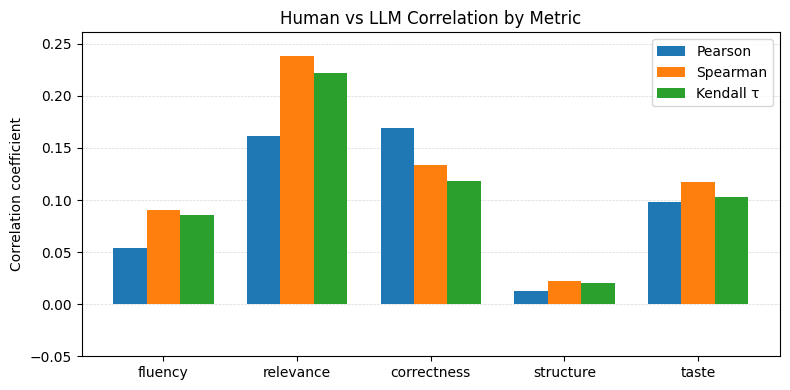

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get this for alignment analysis.
from scipy.stats import pearsonr, spearmanr, kendalltau


HUMAN_EVAL_PATH = "/content/drive/MyDrive/human_evaluated_recipes.json"
LLM_EVAL_PATH = "/content/drive/MyDrive/llm_evaluated_recipes.json"
OUTPUT_PATH = "/content/drive/MyDrive/merged_human_llm_scores.json"


with open(HUMAN_EVAL_PATH, "r") as f:
    human_evals = json.load(f)

with open(LLM_EVAL_PATH, "r") as f:
    llm_evals = json.load(f)

llm_map = {e["recipe_id"]: e for e in llm_evals}

# Merge datasets to allow comparison.
merged = []

for h in human_evals:
    rid = h["recipe_id"]

    if rid not in llm_map:
        continue

    llm = llm_map[rid]

    merged.append({
        "recipe_id": rid,

        # Human scores
        "human_fluency": h["scores"]["fluency"],
        "human_relevance": h["scores"]["relevance"],
        "human_correctness": h["scores"]["correctness"],
        "human_structure": h["scores"]["structure"],
        "human_taste": h["scores"]["taste"],
        "human_avg": h["scores"]["human_score"],

        # LLM scores
        "llm_fluency": llm["llm_scores"]["fluency"],
        "llm_relevance": llm["llm_scores"]["relevance"],
        "llm_correctness": llm["llm_scores"]["correctness"],
        "llm_structure": llm["llm_scores"]["structure"],
        "llm_taste": llm["llm_scores"]["taste"],
        "llm_avg": llm["llm_scores"]["llm_score"],

        "original": h.get("original", ""),
        "improved": h.get("improved", "")
    })

# Save merged dataset.
with open(OUTPUT_PATH, "w") as f:
    json.dump(merged, f, indent=2)

print(f"Merged dataset saved to: {OUTPUT_PATH}")
print(f"Total matched recipes: {len(merged)}")

# Convert it to a dataframe.
df = pd.DataFrame(merged)

# Calculates alignment metrics across all criteria.
criteria = ["fluency", "relevance", "correctness", "structure", "taste"]

# Prints correlations averaged across all runs.
print("\nCORRELATIONS:")

pearsons, spearmans, kendalls = [], [], []

for c in criteria:
    h = df[f"human_{c}"]
    l = df[f"llm_{c}"]

    p = pearsonr(h, l)[0]
    s = spearmanr(h, l)[0]
    k = kendalltau(h, l)[0]

    pearsons.append(p)
    spearmans.append(s)
    kendalls.append(k)

    print(f"\n{c.upper()}:")
    print(f" Pearson   : {p:.4f}")
    print(f" Spearman  : {s:.4f}")
    print(f" Kendall's τ : {k:.4f}")

# Prints bar chart.
x = np.arange(len(criteria))
bar_width = 0.25

all_vals = np.array(pearsons + spearmans + kendalls)

y_min = np.min(all_vals)
y_max = np.max(all_vals)

# Adds padding so bars do not touch edges.
padding = 0.1 * (y_max - y_min if y_max != y_min else 1)

plt.figure(figsize=(8, 4))

# Ensures grid is behind bars.
plt.gca().set_axisbelow(True)

# Makes faint gridlines for readability.
plt.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

plt.bar(x - bar_width, pearsons, width=bar_width, label="Pearson")
plt.bar(x, spearmans, width=bar_width, label="Spearman")
plt.bar(x + bar_width, kendalls, width=bar_width, label="Kendall τ")

plt.xticks(x, criteria)
plt.ylabel("Correlation coefficient")
plt.title("Human vs LLM Correlation by Metric")

# Set lower bound to -0.0.5.
lower_bound = min(-0.05, y_min - padding)
upper_bound = y_max + padding
plt.ylim(lower_bound, upper_bound)

plt.legend()
plt.tight_layout()
plt.show()